In [10]:
import pandas as pd

In [11]:
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
customer_locations = pd.read_csv('olist_customers_dataset.csv')

In [12]:
# STORY 1

In [13]:
reviews["review_score"] = reviews.groupby("order_id")["review_score"].transform("mean")
reviews = reviews.drop_duplicates(subset="order_id")
# some order_ids had more than one review

In [14]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4.0,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5.0,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5.0,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5.0,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [15]:
reviews["order_id"].value_counts().head()

,count
order_id,
90531360ecb1eec2a1fbb265a0db0508,1
5f4a120717a4d152577d7d2ec66c45be,1
10a3f7e9bf88b7dc86a767fd278e5bd2,1
d398e9c82363c12527f71801bf0e6100,1
287445be3e2a5f0d3f5036b2a778d1c5,1


In [16]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [17]:
customer_locations.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [18]:
orders_reviews = pd.merge(
    orders,
    reviews,
    on="order_id",
    how="left"
)
orders_reviews.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [19]:
print(orders.shape[0])
print(orders_reviews.shape[0])

99441
99441


In [20]:
master = pd.merge(
    orders_reviews,
    customer_locations,
    on="customer_id",
    how="left"
)
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [21]:
print("Orders:", orders.shape[0])
print("Master:", master.shape[0])

Orders: 99441
Master: 99441


In [22]:
# so i have basically checked dupplicates by checking to see that my dataset has the same number of rows

In [23]:
#  now I'm checking for missing values
(master.isna().sum() / len(master)) * 100

,0
order_id,0.000000
customer_id,0.000000
order_status,0.000000
order_purchase_timestamp,0.000000
order_approved_at,0.160899
order_delivered_carrier_date,1.793023
order_delivered_customer_date,2.981668
order_estimated_delivery_date,0.000000
review_id,0.772317
review_score,0.772317


In [24]:
master = master.drop(columns=["review_comment_title", "review_comment_message"])
# dropped these columns because they had over 50% of their values missing
# left rows of columns with > 3% missing values

In [25]:
(master.isna().sum() / len(master)) * 100

,0
order_id,0.000000
customer_id,0.000000
order_status,0.000000
order_purchase_timestamp,0.000000
order_approved_at,0.160899
order_delivered_carrier_date,1.793023
order_delivered_customer_date,2.981668
order_estimated_delivery_date,0.000000
review_id,0.772317
review_score,0.772317


In [26]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   review_id                      98673 non-null  object 
 9   review_score                   98673 non-null  float64
 10  review_creation_date           98673 non-null  object 
 11  review_answer_timestamp        98673 non-null  object 
 12  customer_unique_id             99441 non-null 

In [27]:
# STORY 2

In [28]:
# converting from str objects to datetime objects to enable calculation of difference in dates
master['order_delivered_customer_date'] = pd.to_datetime(master['order_delivered_customer_date'])
master['order_estimated_delivery_date'] = pd.to_datetime(master['order_estimated_delivery_date'])


In [29]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  object        
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   review_id                      98673 non-null  object        
 9   review_score                   98673 non-null  float64       
 10  review_creation_date           98673 non-null  object        
 11  review_answer_t

In [30]:
def calculate_delay(df):


  df["days_diff"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days

  df["delivery_status"] = pd.cut(
      df["days_diff"],
      bins=[-1000, 0, 5, 1000],   # edges
      labels=["On Time", "Late", "Super Late"]
  )

  return df

In [31]:
calculate_delay(master)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,days_diff,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-8.0,On Time
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,-6.0,On Time
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,-18.0,On Time
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5.0,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,-13.0,On Time
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5.0,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,-10.0,On Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,e262b3f92d1ce917aa412a9406cf61a6,5.0,2017-03-22 00:00:00,2017-03-23 11:02:08,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,-11.0,On Time
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,29bb71b2760d0f876dfa178a76bc4734,4.0,2018-03-01 00:00:00,2018-03-02 17:50:01,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,-2.0,On Time
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,371579771219f6db2d830d50805977bb,5.0,2017-09-22 00:00:00,2017-09-22 23:10:57,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,-6.0,On Time
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,8ab6855b9fe9b812cd03a480a25058a1,2.0,2018-01-26 00:00:00,2018-01-27 09:16:56,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,-21.0,On Time


In [32]:
master["delivery_status"].value_counts().head()

,count
delivery_status,
On Time,89941
Super Late,3765
Late,2770


In [33]:
master["order_status"].value_counts().head(10)

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [34]:
# excluded observations/orders with order_statuses of 'cancelled' or 'unavailable'

master = master[~master["order_status"].isin(["canceled", "unavailable"])]


In [35]:
master["order_status"].shape

(98207,)

In [36]:
# STORY 3

In [37]:
# finding the customer state with the most counts and assuming that to be the distribution center

master["customer_state"].value_counts()

,count
customer_state,
SP,41127
RJ,12698
MG,11496
RS,5417
PR,4983
SC,3600
BA,3344
DF,2121
ES,2018


In [38]:
# percentage of late orders for each state
late_counts = master[master["delivery_status"] == "Late"].groupby("customer_state")["order_id"].count()

total_counts = master.groupby("customer_state")["order_id"].count()

late_percentage = ((late_counts / total_counts) * 100).round(2).sort_values(ascending=False)

late_percentage

,order_id
customer_state,
AL,8.27
MA,6.93
PI,6.33
ES,4.51
BA,4.46
TO,4.32
MS,4.24
PB,3.95
SC,3.86


<Axes: title={'center': '% Late Orders per State'}, xlabel='customer state', ylabel='number of late orders'>

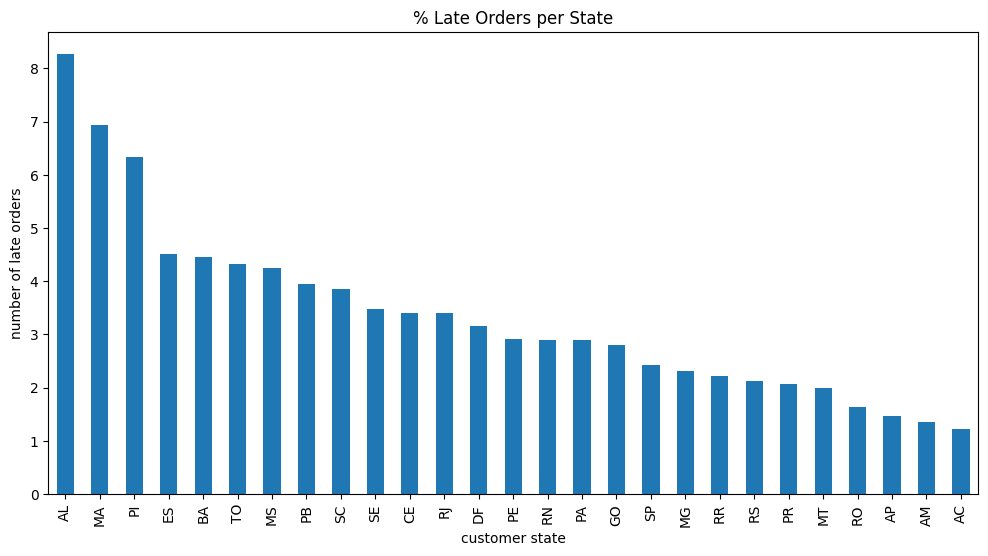

In [39]:
late_percentage.plot(kind="bar",
                     figsize=(12,6),
                     xlabel="customer state",
                     ylabel="number of late orders",
                     title="% Late Orders per State")


In [40]:
from geopy.geocoders import Nominatim
from geopy.distance import geodesic


In [41]:
# calculating the approximate distance from the distribution center state to all other states

geolocator = Nominatim(user_agent="state_centroids", timeout=5)

# São Paulo distribution center
sp_coords = (-23.54, -46.64)


states = ["RJ","MG","RS","PR","SC","BA","DF","ES","GO","PE","CE","PA","MT","MA","MS","PB","PI","RN","AL","SE","TO","RO","AM","AC","AP","RR"]

coords = {}
for state in states:
    location = geolocator.geocode(state + ", Brazil")
    if location:
        coords[state] = (location.latitude, location.longitude)



# Compute distances
distances = {state: geodesic(sp_coords, coords[state]).km for state in coords}

In [42]:
distances

{'RJ': 455.06050382222156,
 'MG': 612.0250103139001,
 'RS': 994.9339646111607,
 'PR': 536.7522359514069,
 'SC': 596.0258223825599,
 'BA': 1341.5745756036285,
 'DF': 868.0519422656009,
 'ES': 801.1534509740511,
 'GO': 918.4405298910925,
 'PE': 1932.3605425784672,
 'CE': 2147.8986824874864,
 'PA': 2185.052090354438,
 'MT': 1569.7637174852784,
 'MA': 2032.8024385706644,
 'MS': 922.2439079660451,
 'PB': 2103.503548748251,
 'PI': 1807.74775440597,
 'RN': 2256.829872517369,
 'AL': 1867.689663677411,
 'SE': 1730.2621588313389,
 'TO': 1412.5364333793243,
 'RO': 2211.39890014486,
 'AM': 2781.1179831814375,
 'AC': 3006.359677964853,
 'AP': 2812.76048394794,
 'RR': 3257.8622453977173}

In [43]:
distance_df = pd.DataFrame(list(distances.items()), columns=["customer_state", "distance_km"])
late_df = late_percentage.reset_index()

state_analysis = pd.merge(late_df, distance_df, on="customer_state", how="left")
print(state_analysis.sort_values("distance_km", ascending=False))


   customer_state  order_id  distance_km
19             RR      2.22  3257.862245
26             AC      1.23  3006.359678
24             AP      1.47  2812.760484
25             AM      1.36  2781.117983
14             RN      2.90  2256.829873
23             RO      1.63  2211.398900
15             PA      2.89  2185.052090
10             CE      3.40  2147.898682
7              PB      3.95  2103.503549
1              MA      6.93  2032.802439
13             PE      2.92  1932.360543
0              AL      8.27  1867.689664
2              PI      6.33  1807.747754
9              SE      3.48  1730.262159
22             MT      2.00  1569.763717
5              TO      4.32  1412.536433
4              BA      4.46  1341.574576
20             RS      2.12   994.933965
6              MS      4.24   922.243908
16             GO      2.80   918.440530
12             DF      3.16   868.051942
3              ES      4.51   801.153451
18             MG      2.31   612.025010
8              S

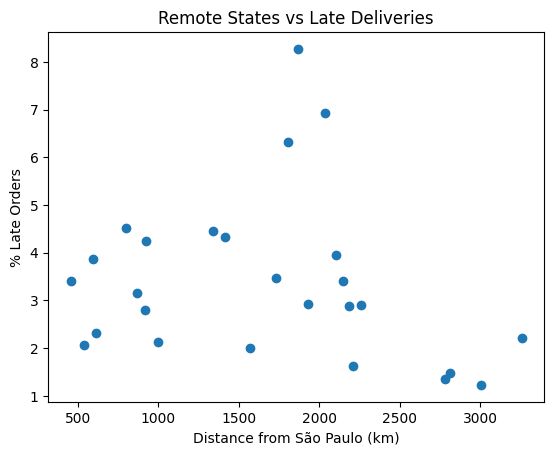

In [44]:
import matplotlib.pyplot as plt

plt.scatter(state_analysis["distance_km"], state_analysis["order_id"])
plt.xlabel("Distance from São Paulo (km)")
plt.ylabel("% Late Orders")
plt.title("Remote States vs Late Deliveries")
plt.show()


In [45]:
# remote states aren't visibly disapproportionately affected

In [46]:
# STORY 4

In [47]:
# excluding missing values
sentiment_vs_days = master.dropna(subset=['review_score', 'days_diff'])

sentiment_vs_days[['days_diff', 'review_score', 'delivery_status']].head()

,days_diff,review_score,delivery_status
0,-8.0,4.0,On Time
1,-6.0,4.0,On Time
2,-18.0,5.0,On Time
3,-13.0,5.0,On Time
4,-10.0,5.0,On Time


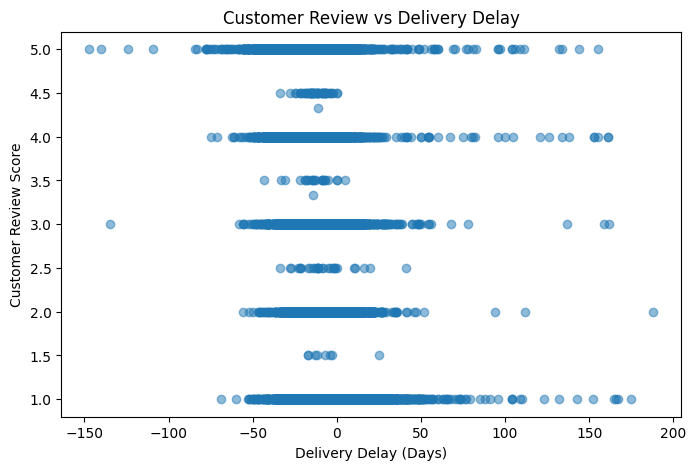

In [48]:
# visualising "Delivery Delay (Days)" vs "Average Review Score (1-5)"
plt.figure(figsize=(8,5))
plt.scatter(sentiment_vs_days['days_diff'], sentiment_vs_days['review_score'], alpha=0.5)
plt.xlabel('Delivery Delay (Days)')
plt.ylabel('Customer Review Score')
plt.title('Customer Review vs Delivery Delay')
plt.show()

# so the more negative the delivery delay is (delivered before estimated date or before time), the higher the review
# a slant in the distribution can be noted - as the delay days increase, the smaller the review score is

In [49]:
avg_review_by_status = sentiment_vs_days.groupby('delivery_status')['review_score'].mean()
avg_review_by_status

/tmp/ipython-input-3544731271.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_review_by_status = sentiment_vs_days.groupby('delivery_status')['review_score'].mean()


,review_score
delivery_status,
On Time,4.290589
Late,2.988795
Super Late,1.738453


In [50]:
# STORY 5 (BONUS)

In [51]:
customer_products = pd.read_csv('olist_products_dataset.csv')
customer_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [52]:
translation_array = pd.read_csv("product_category_name_translation.csv")
translation_array.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [53]:
order_items = pd.read_csv("olist_order_items_dataset.csv")
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [54]:
# Merging order_items with products under product_id to get category name
order_products = order_items.merge(customer_products, on="product_id", how="left")
order_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [55]:
order_products = order_products.merge(
    translation_array,
    on="product_category_name",
    how="left"
)
order_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [56]:
subset = order_products[["order_id", "product_category_name", "product_category_name_english"]]
subset

,order_id,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,ferramentas_jardim,garden_tools
...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,utilidades_domesticas,housewares
112646,fffcd46ef2263f404302a634eb57f7eb,informatica_acessorios,computers_accessories
112647,fffce4705a9662cd70adb13d4a31832d,esporte_lazer,sports_leisure
112648,fffe18544ffabc95dfada21779c9644f,informatica_acessorios,computers_accessories


In [57]:
# STORY 6 - CANDIDATE CHALLENGE

In [58]:
# Merge order_products with master on order_id = complete dataframe
merged_df = master.merge(
    order_products,
    on="order_id",
    how="left"
)

merged_df.head()



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5.0,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5.0,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


In [59]:
late_by_category = merged_df[merged_df["delivery_status"] == "Late"].groupby("product_category_name")["order_id"].count()
total_by_category = merged_df.groupby("product_category_name_english")["order_id"].count()

late_percentage_category = (late_by_category / total_by_category * 100).round(2)
late_percentage_category.sort_values(ascending=False).head(10)


,order_id
audio,3.58
cool_stuff,2.57
consoles_games,2.22
pet_shop,2.06
dvds_blu_ray,1.61
market_place,0.97
agro_industria_e_comercio,NaN
agro_industry_and_commerce,NaN
air_conditioning,NaN
alimentos,NaN


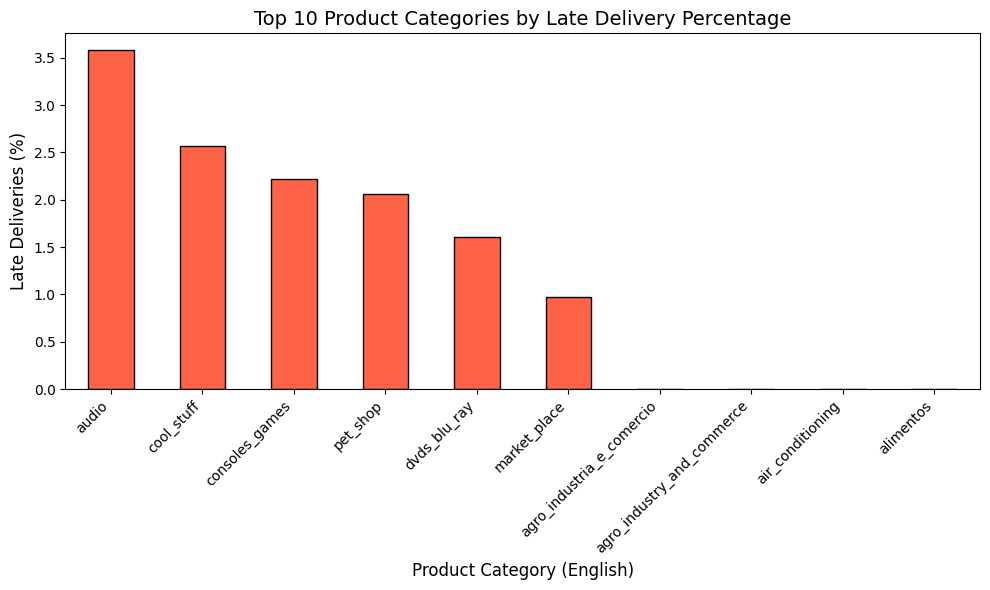

In [60]:
# This gives you the top 10 product categories with the highest lateness %.
import matplotlib.pyplot as plt

# Get top 10 categories by lateness %
top10 = late_percentage_category.sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
top10.plot(kind="bar", color="tomato", edgecolor="black")

plt.title("Top 10 Product Categories by Late Delivery Percentage", fontsize=14)
plt.xlabel("Product Category (English)", fontsize=12)
plt.ylabel("Late Deliveries (%)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()
